In [ ]:
# ── Cell 1: GPU check ─────────────────────────────────────────────
import subprocess
r = subprocess.run(['nvidia-smi'], capture_output=True, text=True)
print(r.stdout if r.returncode == 0 else ' No GPU. Runtime ')

Sun Apr 12 23:25:12 2026       
+-----------------------------------------------------------------------------------------+
| NVIDIA-SMI 580.82.07              Driver Version: 580.82.07      CUDA Version: 13.0     |
+-----------------------------------------+------------------------+----------------------+
| GPU  Name                 Persistence-M | Bus-Id          Disp.A | Volatile Uncorr. ECC |
| Fan  Temp   Perf          Pwr:Usage/Cap |           Memory-Usage | GPU-Util  Compute M. |
|                                         |                        |               MIG M. |
|=========================================+========================+======================|
|   0  Tesla T4                       Off |   00000000:00:04.0 Off |                    0 |
| N/A   69C    P0             32W /   70W |    4361MiB /  15360MiB |      0%      Default |
|                                         |                        |                  N/A |
+-----------------------------------------+-----

In [18]:
# ── Cell 2: Imports ───────────────────────────────────────────────
import torch
import torch.nn as nn
from torch.nn import functional as F
import time, os, json, urllib.request, psutil, copy
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
from collections import defaultdict
from IPython.display import clear_output
import warnings; warnings.filterwarnings('ignore')

device = 'cuda' if torch.cuda.is_available() else 'cpu'
print(f'Device  : {device.upper()}')
if device == 'cuda':
    print(f'GPU     : {torch.cuda.get_device_name(0)}')
    print(f'VRAM    : {torch.cuda.get_device_properties(0).total_memory/1e9:.1f} GB')
print(f'RAM     : {psutil.virtual_memory().total/1e9:.1f} GB')

Device  : CUDA
GPU     : Tesla T4
VRAM    : 15.6 GB
RAM     : 13.6 GB


In [19]:
# ── Cell 3: Dataset ───────────────────────────────────────────────
if not os.path.exists('input.txt'):
    urllib.request.urlretrieve(
        'https://raw.githubusercontent.com/karpathy/char-rnn/master/data/tinyshakespeare/input.txt',
        'input.txt'
    )
    print(' Downloaded tiny shakespeare')

with open('input.txt', 'r', encoding='utf-8') as f:
    text = f.read()

chars      = sorted(list(set(text)))
vocab_size = len(chars)
stoi = {ch: i for i, ch in enumerate(chars)}
itos = {i: ch for i, ch in enumerate(chars)}
encode = lambda s: [stoi[c] for c in s]
decode = lambda l: ''.join([itos[i] for i in l])

data       = torch.tensor(encode(text), dtype=torch.long)
n          = int(0.9 * len(data))
train_data = data[:n]
val_data   = data[n:]
print(f'Vocab: {vocab_size} | Train: {len(train_data):,} | Val: {len(val_data):,}')

Vocab: 65 | Train: 1,003,854 | Val: 111,540


In [20]:
# ── Cell 4: Hyperparameters ───────────────────────────────────────
BATCH_SIZE    = 64
BLOCK_SIZE    = 256
MAX_ITERS     = 3000
EVAL_INTERVAL = 300
EVAL_ITERS    = 100
LEARNING_RATE = 3e-4
N_LAYER       = 6
N_EMBD        = 384
N_HEAD        = 6
DROPOUT       = 0.2
SEED          = 1337   # SAME seed for both runs — critical for fair comparison

CONFIGS = [
    {'name': 'ReLU', 'act': nn.ReLU,  'color': '#ff6b6b'},
    {'name': 'GELU', 'act': nn.GELU,  'color': '#00d4ff'},
]

BG, PANEL, GRID, TXT = '#0f0f1a', '#1a1a2e', '#2a2a4a', '#e0e0f0'

tokens_per_batch = BATCH_SIZE * BLOCK_SIZE
print(f'Tokens/batch : {tokens_per_batch:,}')
print(f'Total iters  : {MAX_ITERS} × 2 runs = {MAX_ITERS*2:,}')
print(f'Seed         : {SEED} (identical for both runs)')

Tokens/batch : 16,384
Total iters  : 3000 × 2 runs = 6,000
Seed         : 1337 (identical for both runs)


In [21]:
# ── Cell 5: Instrumented model ────────────────────────────────────
#
# Key design: FeedForward stores its activation OUTPUT via a forward hook.
# After each eval step we read & clear those buffers.
# This adds zero overhead during normal forward pass.

def get_batch(split):
    d  = train_data if split == 'train' else val_data
    ix = torch.randint(len(d) - BLOCK_SIZE, (BATCH_SIZE,))
    x  = torch.stack([d[i:i+BLOCK_SIZE]     for i in ix])
    y  = torch.stack([d[i+1:i+BLOCK_SIZE+1] for i in ix])
    return x.to(device), y.to(device)


class Head(nn.Module):
    def __init__(self):
        super().__init__()
        hs = N_EMBD // N_HEAD
        self.key   = nn.Linear(N_EMBD, hs, bias=False)
        self.query = nn.Linear(N_EMBD, hs, bias=False)
        self.value = nn.Linear(N_EMBD, hs, bias=False)
        self.register_buffer('tril', torch.tril(torch.ones(BLOCK_SIZE, BLOCK_SIZE)))
        self.dropout = nn.Dropout(DROPOUT)

    def forward(self, x):
        B, T, C = x.shape
        k = self.key(x); q = self.query(x)
        wei = q @ k.transpose(-2,-1) * k.shape[-1]**-0.5
        wei = wei.masked_fill(self.tril[:T,:T]==0, float('-inf'))
        wei = F.softmax(wei, dim=-1)
        wei = self.dropout(wei)
        return wei @ self.value(x)


class MultiHeadAttention(nn.Module):
    def __init__(self):
        super().__init__()
        hs = N_EMBD // N_HEAD
        self.heads   = nn.ModuleList([Head() for _ in range(N_HEAD)])
        self.proj    = nn.Linear(hs * N_HEAD, N_EMBD)
        self.dropout = nn.Dropout(DROPOUT)

    def forward(self, x):
        return self.dropout(self.proj(torch.cat([h(x) for h in self.heads], dim=-1)))


class FeedForward(nn.Module):
    """Instrumented FFN — stores post-activation output for analysis."""
    def __init__(self, act_fn):
        super().__init__()
        self.fc1     = nn.Linear(N_EMBD, 4 * N_EMBD)
        self.act     = act_fn()
        self.fc2     = nn.Linear(4 * N_EMBD, N_EMBD)
        self.dropout = nn.Dropout(DROPOUT)
        # buffer — filled during forward, read externally
        self._act_out = None

    def forward(self, x):
        h = self.act(self.fc1(x))   # shape: (B, T, 4*N_EMBD)
        self._act_out = h.detach()  # store for analysis (no grad)
        return self.dropout(self.fc2(h))


class Block(nn.Module):
    def __init__(self, act_fn):
        super().__init__()
        self.sa   = MultiHeadAttention()
        self.ffwd = FeedForward(act_fn)
        self.ln1  = nn.LayerNorm(N_EMBD)
        self.ln2  = nn.LayerNorm(N_EMBD)

    def forward(self, x):
        x = x + self.sa(self.ln1(x))
        x = x + self.ffwd(self.ln2(x))
        return x


class GPTLanguageModel(nn.Module):
    def __init__(self, act_fn):
        super().__init__()
        self.token_embedding_table    = nn.Embedding(vocab_size, N_EMBD)
        self.position_embedding_table = nn.Embedding(BLOCK_SIZE, N_EMBD)
        self.blocks  = nn.Sequential(*[Block(act_fn) for _ in range(N_LAYER)])
        self.ln_f    = nn.LayerNorm(N_EMBD)
        self.lm_head = nn.Linear(N_EMBD, vocab_size)
        self.apply(self._init_weights)

    def _init_weights(self, m):
        if isinstance(m, nn.Linear):
            torch.nn.init.normal_(m.weight, mean=0.0, std=0.02)
            if m.bias is not None: torch.nn.init.zeros_(m.bias)
        elif isinstance(m, nn.Embedding):
            torch.nn.init.normal_(m.weight, mean=0.0, std=0.02)

    def forward(self, idx, targets=None):
        B, T    = idx.shape
        x       = self.token_embedding_table(idx) + \
                  self.position_embedding_table(torch.arange(T, device=device))
        x       = self.ln_f(self.blocks(x))
        logits  = self.lm_head(x)
        loss    = None
        if targets is not None:
            B, T, C = logits.shape
            loss = F.cross_entropy(logits.view(B*T, C), targets.view(B*T))
        return logits, loss

    def get_ffn_layers(self):
        """Return list of FeedForward modules (one per block)."""
        return [block.ffwd for block in self.blocks]


@torch.no_grad()
def estimate_loss(model):
    model.eval()
    out = {}
    for split in ['train', 'val']:
        losses = torch.zeros(EVAL_ITERS)
        for k in range(EVAL_ITERS):
            X, Y = get_batch(split); _, loss = model(X, Y)
            losses[k] = loss.item()
        out[split] = losses.mean().item()
    model.train()
    return out


print('Instrumented model ready')

Instrumented model ready


In [22]:
# ── Cell 6: Metrics collectors ────────────────────────────────────

@torch.no_grad()
def collect_activation_stats(model):
    model.eval()
    x, y = get_batch('train')
    model(x, y)

    stats = {}

    for i, ffn in enumerate(model.get_ffn_layers()):
        act = ffn._act_out.float().cpu()
        flat = act.reshape(-1).numpy()

        counts, bin_edges = np.histogram(flat, bins=60, range=(-3.0, 3.0))

        stats[str(i)] = {
            'mean'        : float(flat.mean()),
            'std'         : float(flat.std()),

            #  CORE METRICS
            'sparsity'    : float((flat == 0.0).mean()),             # exact zeros
            'near_zero'   : float((np.abs(flat) < 0.01).mean()),     # soft inactivity
            'dead'        : float((flat <= 0).mean()),               # KEY: ReLU killer metric

            #  distribution shape
            'positive'    : float((flat > 0).mean()),
            'negative'    : float((flat < 0).mean()),

            #  histogram
            'hist_counts' : counts.tolist(),
            'hist_edges'  : bin_edges.tolist(),
        }

    model.train()
    return stats


def collect_gradient_norms(model):
    norms = {}

    for i, ffn in enumerate(model.get_ffn_layers()):
        g1 = ffn.fc1.weight.grad
        g2 = ffn.fc2.weight.grad

        if g1 is not None and g2 is not None:
            g1_flat = g1.view(-1)
            g2_flat = g2.view(-1)

            norms[str(i)] = {
                'fc1'  : g1.norm(2).item(),
                'fc2'  : g2.norm(2).item(),
                'mean' : (g1.norm(2).item() + g2.norm(2).item()) / 2,

                #  NEW (important)
                'fc1_std': g1_flat.std().item(),
                'fc2_std': g2_flat.std().item(),

                # signal-to-noise ratio proxy
                'fc1_snr': g1.norm(2).item() / (g1_flat.std().item() + 1e-8),
                'fc2_snr': g2.norm(2).item() / (g2_flat.std().item() + 1e-8),
            }

    return norms


print(' Metrics collectors ready')

 Metrics collectors ready


In [23]:
# ── Cell 7: Live dashboard ────────────────────────────────────────

def live_dashboard(run_name, color, iters_log,
                   train_losses, val_losses,
                   gpu_mems, ram_usages, tokens_list, tok_rates,
                   act_stats_history, grad_norm_history,
                   completed_runs):

    fig = plt.figure(figsize=(20, 13))
    fig.patch.set_facecolor(BG)
    gs  = gridspec.GridSpec(3, 4, figure=fig, hspace=0.58, wspace=0.38)

    def ax_(r, c, colspan=1):
        return fig.add_subplot(gs[r, c:c+colspan])

    ax_loss    = ax_(0, 0, 2)   # train+val loss (wide)
    ax_compare = ax_(0, 2, 2)   # cross-run val loss comparison (wide)
    ax_gpu     = ax_(1, 0)
    ax_ram     = ax_(1, 1)
    ax_tokens  = ax_(1, 2)
    ax_tokrate = ax_(1, 3)
    ax_sparse  = ax_(2, 0, 2)   # sparsity per layer (wide)
    ax_grad    = ax_(2, 2, 2)   # gradient norms per layer (wide)

    def style(ax, title, xlabel='Iteration', ylabel=''):
        ax.set_facecolor(PANEL)
        for s in ax.spines.values(): s.set_color(GRID)
        ax.tick_params(colors=TXT, labelsize=8)
        ax.set_title(title, color=TXT, fontsize=9, fontweight='bold', pad=6)
        ax.grid(True, color=GRID, linewidth=0.4, linestyle='--')
        if xlabel: ax.set_xlabel(xlabel, color=TXT, fontsize=8)
        if ylabel: ax.set_ylabel(ylabel, color=TXT, fontsize=8)

    # ── 1. Loss curves ───────────────────────────────────────────
    style(ax_loss, f'{run_name} — Train & Val Loss', ylabel='Loss')
    if iters_log:
        ax_loss.plot(iters_log, train_losses, color=color, lw=2,
                     marker='o', ms=4, label=f'Train {train_losses[-1]:.4f}')
        ax_loss.plot(iters_log, val_losses, color='white', lw=2,
                     marker='s', ms=4, linestyle='--',
                     label=f'Val   {val_losses[-1]:.4f}')
        ax_loss.fill_between(iters_log, train_losses, alpha=0.12, color=color)
        ax_loss.fill_between(iters_log, val_losses,   alpha=0.08, color='white')
        ax_loss.legend(facecolor=PANEL, edgecolor=GRID, labelcolor=TXT, fontsize=8)
    ax_loss.set_xlim(0, MAX_ITERS)

    # ── 2. Cross-run comparison ──────────────────────────────────
    style(ax_compare, ' ReLU vs GELU — Val Loss', ylabel='Val Loss')
    for cfg_name, res in completed_runs.items():
        c2 = next(c['color'] for c in CONFIGS if c['name'] == cfg_name)
        ax_compare.plot(res['iters_log'], res['val_losses'],
                        color=c2, lw=2, label=f"{cfg_name} final={res['final_val']:.4f}")
    if val_losses:
        ax_compare.plot(iters_log, val_losses, color=color, lw=2,
                        linestyle=':', label=f'{run_name} (running)')
    ax_compare.legend(facecolor=PANEL, edgecolor=GRID, labelcolor=TXT, fontsize=8)
    ax_compare.set_xlim(0, MAX_ITERS)

    # ── 3-6. System metrics ──────────────────────────────────────
    for ax, data, col, label, unit in [
        (ax_gpu,     gpu_mems,   '#a8ff78', '  GPU Mem',    'MB'),
        (ax_ram,     ram_usages, '#ffcc02', '  RAM',         'MB'),
        (ax_tokens,  [t/1e6 for t in tokens_list], '#da77f2', '  Tokens', 'M'),
        (ax_tokrate, tok_rates,  '#ffa94d', '  Tok/sec',    'tok/s'),
    ]:
        style(ax, label, ylabel=unit)
        if data:
            ax.plot(iters_log, data, color=col, lw=2, marker='o', ms=3)
            ax.fill_between(iters_log, data, alpha=0.15, color=col)
            ax.set_title(f'{label}  [{data[-1]:,.1f}]',
                         color=TXT, fontsize=9, fontweight='bold', pad=6)
        ax.set_xlim(0, MAX_ITERS)

    # ── 7. Sparsity / near-zero per layer (latest snapshot) ──────
    style(ax_sparse, ' Neuron Utilization — % Near-Zero per Layer',
          xlabel='Layer', ylabel='% Near-Zero Activations')
    if act_stats_history:
        latest = act_stats_history[-1]
        layers     = sorted(latest.keys())
        sparsities = [latest[l]['near_zero'] * 100 for l in layers]
        bar_cols   = [color] * len(layers)
        ax_sparse.bar([f'L{l}' for l in layers], sparsities,
                      color=bar_cols, alpha=0.8, width=0.6)
        ax_sparse.set_ylim(0, 100)
        for l, s in zip(layers, sparsities):
            ax_sparse.annotate(f'{s:.1f}%', (f'L{l}', s),
                               textcoords='offset points', xytext=(0,4),
                               ha='center', color=TXT, fontsize=8)
        # overlay completed run if exists
        if completed_runs:
            other_name = list(completed_runs.keys())[0]
            other_res  = completed_runs[other_name]
            if other_res.get('act_stats_final'):
                other_s = [other_res['act_stats_final'][str(l)]['near_zero']*100
                           for l in layers]
                other_c = next(c['color'] for c in CONFIGS if c['name']==other_name)
                ax_sparse.plot([f'L{l}' for l in layers], other_s,
                               color=other_c, lw=2, marker='o', ms=5,
                               label=other_name, linestyle='--')
                ax_sparse.plot([f'L{l}' for l in layers], sparsities,
                               color=color, lw=2, marker='s', ms=5,
                               label=run_name)
                ax_sparse.legend(facecolor=PANEL, edgecolor=GRID,
                                 labelcolor=TXT, fontsize=8)

    # ── 8. Gradient norms per layer ──────────────────────────────
    style(ax_grad, ' Gradient Norms per FFN Layer (latest step)',
          xlabel='Layer', ylabel='Gradient L2 Norm')
    if grad_norm_history:
        latest_g = grad_norm_history[-1]
        layers_g = sorted(latest_g.keys())
        fc1_norms = [latest_g[l]['fc1'] for l in layers_g]
        fc2_norms = [latest_g[l]['fc2'] for l in layers_g]
        x_pos = np.arange(len(layers_g))
        ax_grad.bar(x_pos - 0.2, fc1_norms, 0.35, label='fc1 (pre-act)',
                    color=color, alpha=0.8)
        ax_grad.bar(x_pos + 0.2, fc2_norms, 0.35, label='fc2 (post-act)',
                    color='white', alpha=0.5)
        ax_grad.set_xticks(x_pos)
        ax_grad.set_xticklabels([f'L{l}' for l in layers_g], color=TXT)
        ax_grad.legend(facecolor=PANEL, edgecolor=GRID, labelcolor=TXT, fontsize=8)

    # ── title ─────────────────────────────────────────────────────
    pct = int(100 * iters_log[-1] / MAX_ITERS) if iters_log else 0
    fig.suptitle(
        f'ReLU vs GELU Experiment  |  Running: {run_name}  |  '
        f'Progress: {pct}%  |  Device: {device.upper()}',
        color=TXT, fontsize=12, fontweight='bold', y=0.998
    )

    plt.savefig(f'dashboard_{run_name.lower()}.png', dpi=110,
                bbox_inches='tight', facecolor=BG)
    clear_output(wait=True)
    plt.show()
    plt.close(fig)

print(' Live dashboard ready')

 Live dashboard ready


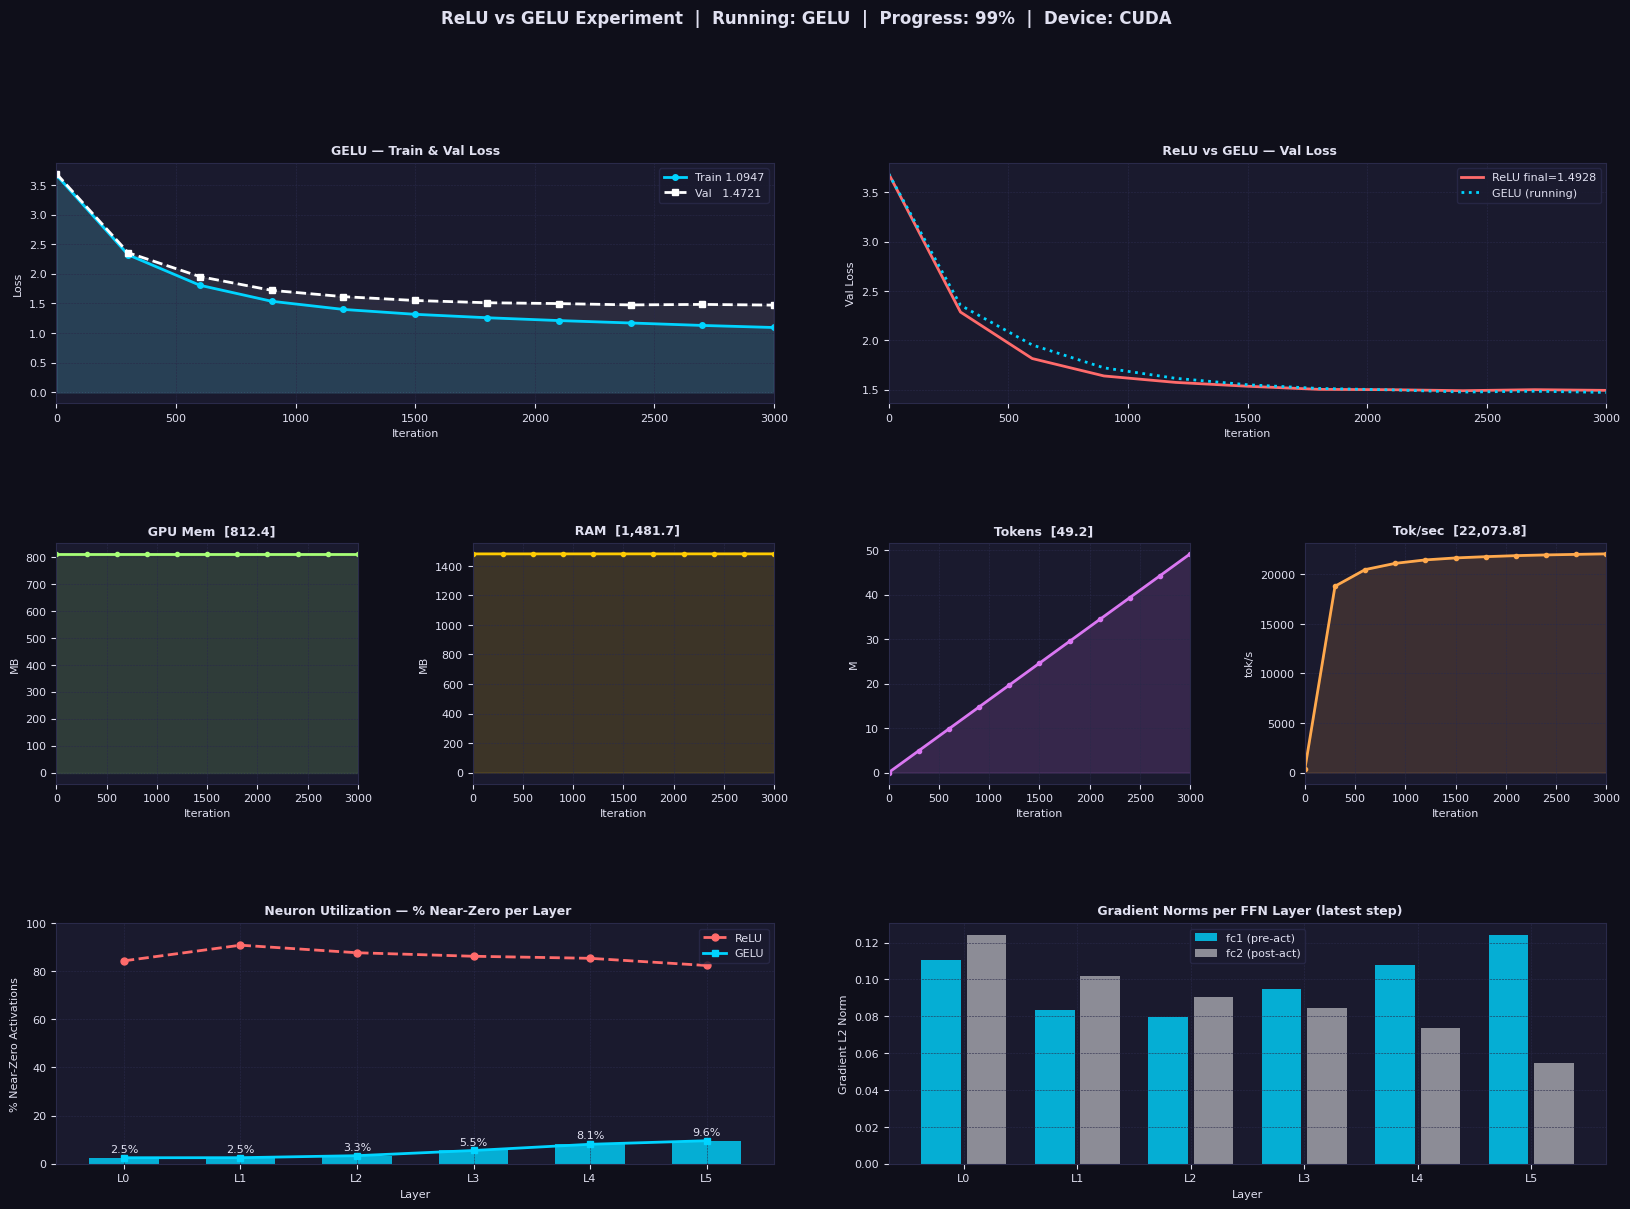

  iter 2999 | train 1.0947 | val 1.4721 | gpu 812MB | ram 1482MB | tokens 49.2M | tok/s 22,074 | L0 near-zero 2.5%

 GELU done | 37.2 min | final val: 1.4721

 Both runs complete!


In [24]:
# ── Cell 9: Training loop ─────────────────────────────────────────
all_results = {}

for cfg in CONFIGS:
    run_name = cfg['name']
    act_fn   = cfg['act']
    color    = cfg['color']

    print(f'\n{"="*60}')
    print(f'RUNNING: {run_name}')
    print(f'{"="*60}')

    torch.manual_seed(SEED)
    if device == 'cuda': torch.cuda.manual_seed(SEED)

    model     = GPTLanguageModel(act_fn).to(device)
    optimizer = torch.optim.AdamW(model.parameters(), lr=LEARNING_RATE)
    print(f'Parameters : {sum(p.numel() for p in model.parameters())/1e6:.2f} M')

    iters_log         = []
    train_losses      = []
    val_losses        = []
    gpu_mems          = []
    ram_usages        = []
    tokens_list       = []
    tok_rates         = []
    act_stats_history = []
    grad_norm_history = []
    tokens_processed  = 0
    t0 = time.time()

    for it in range(MAX_ITERS):
        xb, yb  = get_batch('train')
        _, loss = model(xb, yb)
        optimizer.zero_grad(set_to_none=True)
        loss.backward()

        if it % EVAL_INTERVAL == 0 or it == MAX_ITERS - 1:
            gnorms = collect_gradient_norms(model)   # before step
            grad_norm_history.append(gnorms)

        optimizer.step()
        tokens_processed += tokens_per_batch

        if it % EVAL_INTERVAL == 0 or it == MAX_ITERS - 1:
            losses  = estimate_loss(model)
            astats  = collect_activation_stats(model)  # str keys guaranteed
            elapsed = time.time() - t0

            gpu_mb = torch.cuda.memory_allocated()/1e6 if device=='cuda' else 0.0
            ram_mb = psutil.Process().memory_info().rss / 1e6
            tok_s  = tokens_processed / elapsed

            iters_log.append(it)
            train_losses.append(losses['train'])
            val_losses.append(losses['val'])
            gpu_mems.append(gpu_mb)
            ram_usages.append(ram_mb)
            tokens_list.append(tokens_processed)
            tok_rates.append(tok_s)
            act_stats_history.append(astats)

            live_dashboard(
                run_name, color, iters_log,
                train_losses, val_losses,
                gpu_mems, ram_usages, tokens_list, tok_rates,
                act_stats_history, grad_norm_history,
                all_results
            )
            print(
                f'  iter {it:>4} | '
                f'train {losses["train"]:.4f} | '
                f'val {losses["val"]:.4f} | '
                f'gpu {gpu_mb:.0f}MB | '
                f'ram {ram_mb:.0f}MB | '
                f'tokens {tokens_processed/1e6:.1f}M | '
                f'tok/s {tok_s:,.0f} | '
                f'L0 near-zero {astats["0"]["near_zero"]*100:.1f}%'  # str key
            )

    elapsed = time.time() - t0
    all_results[run_name] = {
        'name'             : run_name,
        'iters_log'        : iters_log,
        'train_losses'     : train_losses,
        'val_losses'       : val_losses,
        'gpu_mems'         : gpu_mems,
        'ram_usages'       : ram_usages,
        'tokens_list'      : tokens_list,
        'tok_rates'        : tok_rates,
        'act_stats_final'  : act_stats_history[-1],   # str keys
        'act_stats_history': act_stats_history,
        'grad_norm_history': grad_norm_history,
        'final_train'      : train_losses[-1],
        'final_val'        : val_losses[-1],
        'elapsed_sec'      : elapsed,
        'tok_per_sec'      : tokens_processed / elapsed,
    }

    with open('relu_vs_gelu_results.json', 'w') as f:
        json.dump(all_results, f, indent=2)

    del model, optimizer
    if device == 'cuda': torch.cuda.empty_cache()
    print(f'\n {run_name} done | {elapsed/60:.1f} min | final val: {val_losses[-1]:.4f}')

print('\n Both runs complete!')

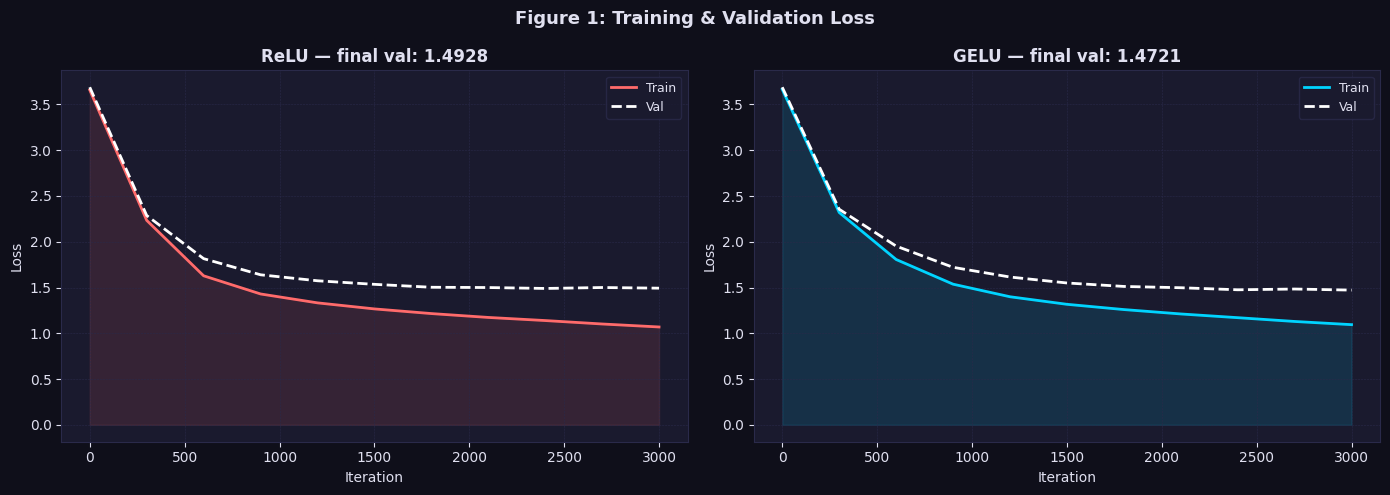

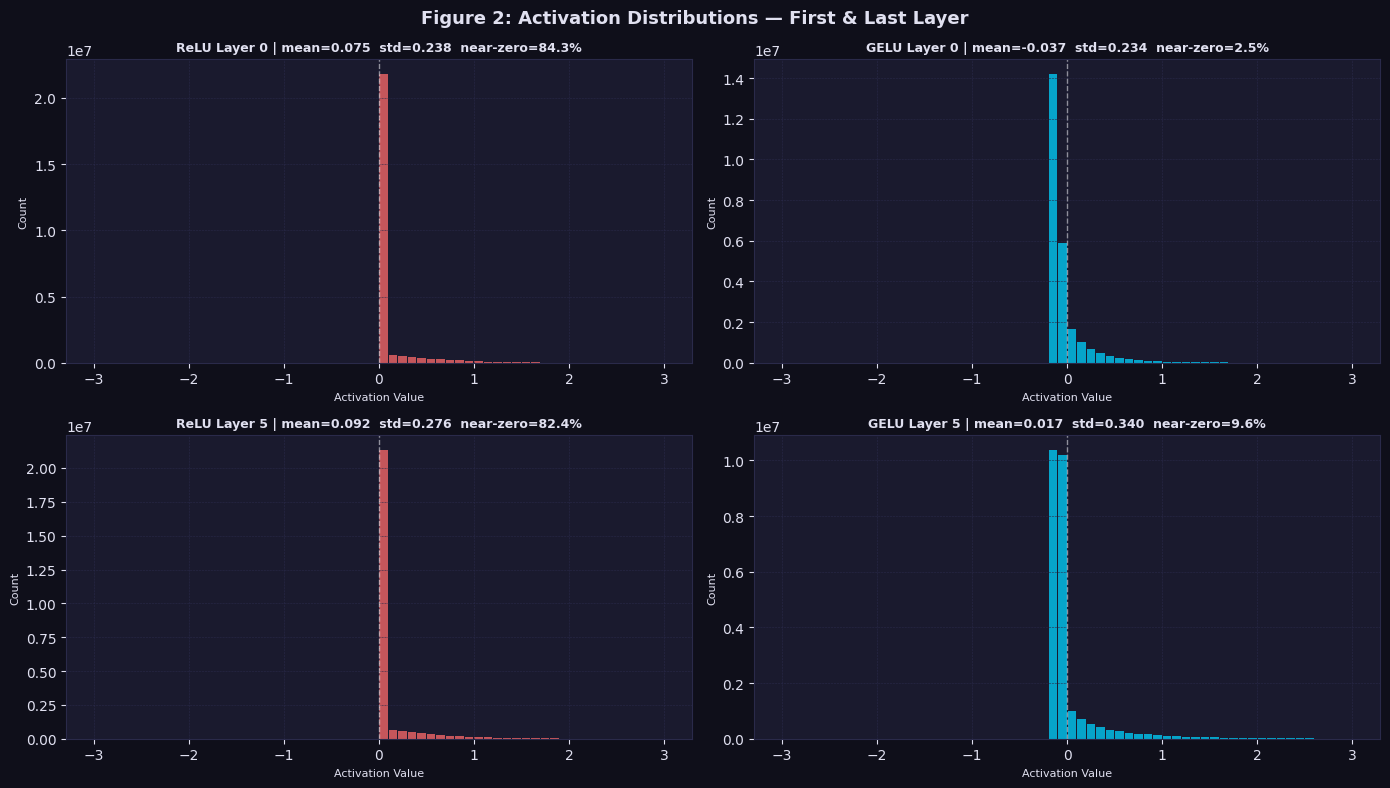

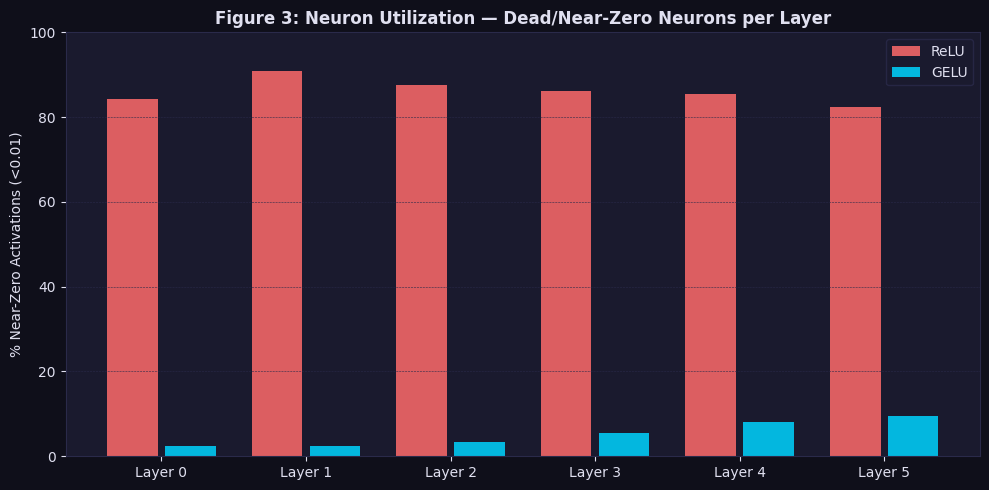

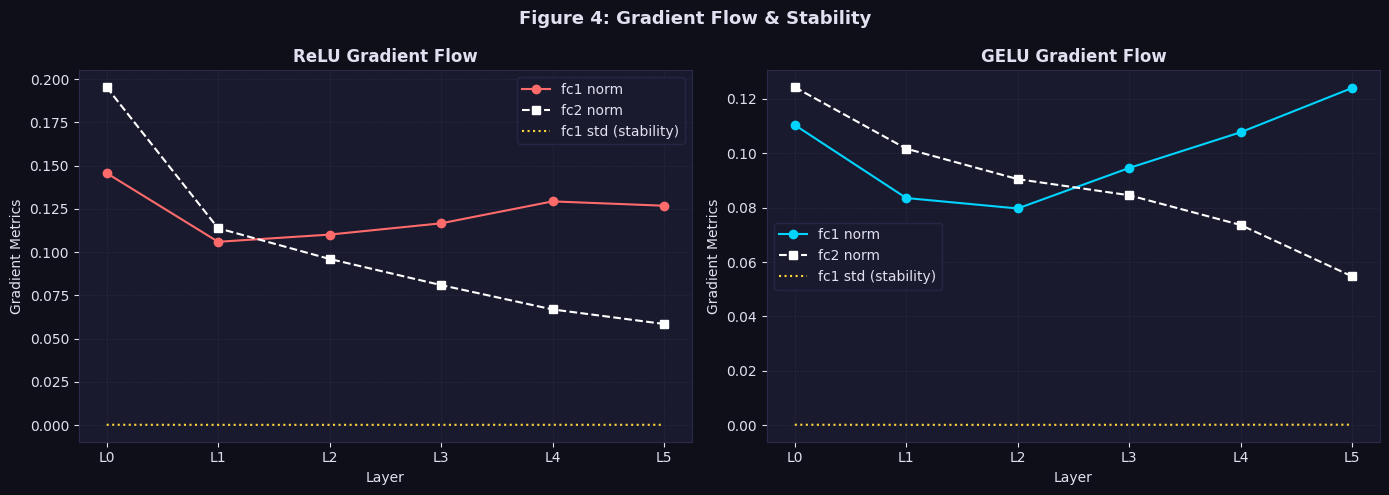


 Saved: fig1_loss_curves.png | fig2_activation_histograms.png
 fig3_neuron_utilization.png | fig4_gradient_flow.png


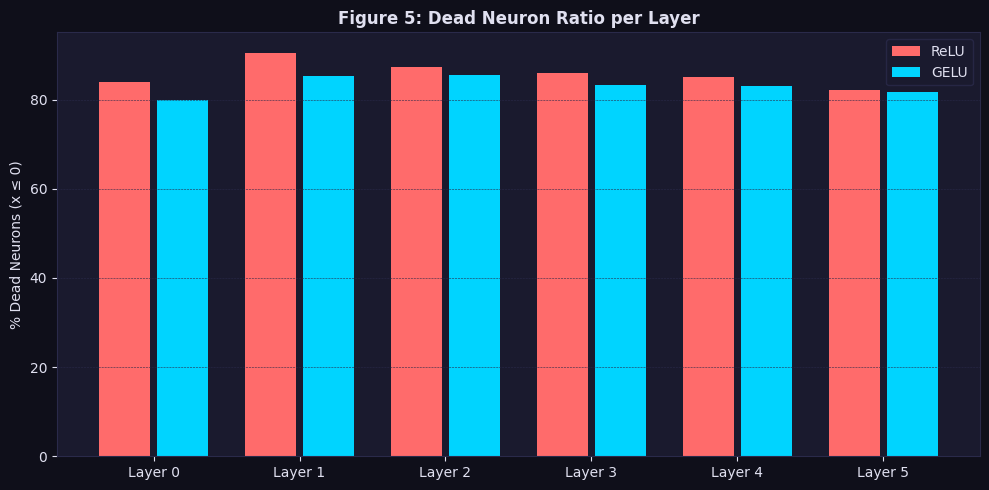

In [25]:
# ── Cell 9: Publication figures ───────────────────────────────────
with open('relu_vs_gelu_results.json') as f:
    all_results = json.load(f)

relu = all_results['ReLU']
gelu = all_results['GELU']

# ── Fig 1: Loss curves side by side ──────────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
fig.patch.set_facecolor(BG)
for ax, res, color in [(axes[0], relu, '#ff6b6b'), (axes[1], gelu, '#00d4ff')]:
    ax.set_facecolor(PANEL)
    for s in ax.spines.values(): s.set_color(GRID)
    ax.tick_params(colors=TXT)
    ax.grid(True, color=GRID, lw=0.4, linestyle='--')
    ax.plot(res['iters_log'], res['train_losses'], color=color, lw=2, label='Train')
    ax.plot(res['iters_log'], res['val_losses'],   color='white', lw=2,
            linestyle='--', label='Val')
    ax.fill_between(res['iters_log'], res['train_losses'], alpha=0.12, color=color)
    ax.set_title(f"{res['name']} — final val: {res['final_val']:.4f}",
                 color=TXT, fontsize=12, fontweight='bold')
    ax.set_xlabel('Iteration', color=TXT)
    ax.set_ylabel('Loss', color=TXT)
    ax.legend(facecolor=PANEL, edgecolor=GRID, labelcolor=TXT, fontsize=9)
fig.suptitle('Figure 1: Training & Validation Loss', color=TXT, fontsize=13, fontweight='bold')
plt.tight_layout()
plt.savefig('fig1_loss_curves.png', dpi=150, bbox_inches='tight', facecolor=BG)
plt.show(); plt.close()

# ── Fig 2: Activation histograms — layer 0 and layer 5 ───────────
fig, axes = plt.subplots(2, 2, figsize=(14, 8))
fig.patch.set_facecolor(BG)
for row, layer_idx in enumerate([0, N_LAYER-1]):
    for col, (res, color) in enumerate([(relu,'#ff6b6b'), (gelu,'#00d4ff')]):
        ax = axes[row][col]
        ax.set_facecolor(PANEL)
        for s in ax.spines.values(): s.set_color(GRID)
        ax.tick_params(colors=TXT)
        ax.grid(True, color=GRID, lw=0.4, linestyle='--')
        stats = res['act_stats_final'][str(layer_idx)]
        edges  = np.array(stats['hist_edges'])
        counts = np.array(stats['hist_counts'])
        centers = (edges[:-1] + edges[1:]) / 2
        ax.bar(centers, counts, width=(edges[1]-edges[0])*0.9,
               color=color, alpha=0.75)
        ax.axvline(0, color='white', lw=1, linestyle='--', alpha=0.5)
        sparsity_pct = stats['near_zero'] * 100
        ax.set_title(
            f"{res['name']} Layer {layer_idx} | "
            f"mean={stats['mean']:.3f}  std={stats['std']:.3f}  "
            f"near-zero={sparsity_pct:.1f}%",
            color=TXT, fontsize=9, fontweight='bold'
        )
        ax.set_xlabel('Activation Value', color=TXT, fontsize=8)
        ax.set_ylabel('Count', color=TXT, fontsize=8)
fig.suptitle('Figure 2: Activation Distributions — First & Last Layer',
             color=TXT, fontsize=13, fontweight='bold')
plt.tight_layout()
plt.savefig('fig2_activation_histograms.png', dpi=150, bbox_inches='tight', facecolor=BG)
plt.show(); plt.close()

# ── Fig 3: Neuron utilization — near-zero % per layer ────────────
fig, ax = plt.subplots(figsize=(10, 5))
fig.patch.set_facecolor(BG); ax.set_facecolor(PANEL)
for s in ax.spines.values(): s.set_color(GRID)
ax.tick_params(colors=TXT)
ax.grid(True, color=GRID, lw=0.4, linestyle='--', axis='y')

layers = list(range(N_LAYER))
x = np.arange(len(layers))
relu_nz = [relu['act_stats_final'][str(l)]['near_zero']*100 for l in layers]
gelu_nz = [gelu['act_stats_final'][str(l)]['near_zero']*100 for l in layers]
ax.bar(x-0.2, relu_nz, 0.35, color='#ff6b6b', alpha=0.85, label='ReLU')
ax.bar(x+0.2, gelu_nz, 0.35, color='#00d4ff', alpha=0.85, label='GELU')
ax.set_xticks(x); ax.set_xticklabels([f'Layer {l}' for l in layers], color=TXT)
ax.set_ylim(0, 100)
ax.set_ylabel('% Near-Zero Activations (<0.01)', color=TXT)
ax.set_title('Figure 3: Neuron Utilization — Dead/Near-Zero Neurons per Layer',
             color=TXT, fontsize=12, fontweight='bold')
ax.legend(facecolor=PANEL, edgecolor=GRID, labelcolor=TXT, fontsize=10)
plt.tight_layout()
plt.savefig('fig3_neuron_utilization.png', dpi=150, bbox_inches='tight', facecolor=BG)
plt.show(); plt.close()

# ── Fig 4: Gradient norms per layer ──────────────────────────────
# ── Fig 4: Gradient Flow (with stability) ─────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
fig.patch.set_facecolor(BG)

for ax, res, color in [(axes[0], relu, '#ff6b6b'),
                       (axes[1], gelu, '#00d4ff')]:

    ax.set_facecolor(PANEL)
    for s in ax.spines.values(): s.set_color(GRID)
    ax.tick_params(colors=TXT)
    ax.grid(True, color=GRID, lw=0.4, linestyle='--')

    grad_stats = res['grad_norm_history'][-1]
    layers = sorted(grad_stats.keys(), key=lambda x: int(x))
    x = np.arange(len(layers))

    fc1 = [grad_stats[l]['fc1'] for l in layers]
    fc2 = [grad_stats[l]['fc2'] for l in layers]

    # new: gradient variance
    fc1_std = [grad_stats[l]['fc1_std'] for l in layers]

    ax.plot(x, fc1, marker='o', label='fc1 norm', color=color)
    ax.plot(x, fc2, marker='s', linestyle='--', label='fc2 norm', color='white')

    # overlay stability
    ax.plot(x, fc1_std, linestyle=':', label='fc1 std (stability)', color='#ffd43b')

    ax.set_xticks(x)
    ax.set_xticklabels([f'L{l}' for l in layers], color=TXT)

    ax.set_xlabel('Layer', color=TXT)
    ax.set_ylabel('Gradient Metrics', color=TXT)

    ax.set_title(f"{res['name']} Gradient Flow",
                 color=TXT, fontsize=12, fontweight='bold')

    ax.legend(facecolor=PANEL, edgecolor=GRID, labelcolor=TXT)

fig.suptitle('Figure 4: Gradient Flow & Stability',
             color=TXT, fontsize=13, fontweight='bold')

plt.tight_layout()
plt.savefig('fig4_gradient_flow.png', dpi=150,
            bbox_inches='tight', facecolor=BG)
plt.show()
plt.close()

print('\n Saved: fig1_loss_curves.png | fig2_activation_histograms.png')
print(' fig3_neuron_utilization.png | fig4_gradient_flow.png')

# ── Fig 5: Dead Neurons (critical insight) ────────────────────────
fig, ax = plt.subplots(figsize=(10, 5))
fig.patch.set_facecolor(BG)
ax.set_facecolor(PANEL)

for s in ax.spines.values(): s.set_color(GRID)
ax.tick_params(colors=TXT)
ax.grid(True, color=GRID, lw=0.4, linestyle='--', axis='y')

layers = [str(i) for i in range(N_LAYER)]
x = np.arange(len(layers))

relu_dead = [relu['act_stats_final'][l]['dead'] * 100 for l in layers]
gelu_dead = [gelu['act_stats_final'][l]['dead'] * 100 for l in layers]

ax.bar(x - 0.2, relu_dead, 0.35, color='#ff6b6b', label='ReLU')
ax.bar(x + 0.2, gelu_dead, 0.35, color='#00d4ff', label='GELU')

ax.set_xticks(x)
ax.set_xticklabels([f'Layer {l}' for l in layers], color=TXT)
ax.set_ylabel('% Dead Neurons (x ≤ 0)', color=TXT)

ax.set_title('Figure 5: Dead Neuron Ratio per Layer',
             color=TXT, fontsize=12, fontweight='bold')

ax.legend(facecolor=PANEL, edgecolor=GRID, labelcolor=TXT)

plt.tight_layout()
plt.savefig('fig5_dead_neurons.png', dpi=150,
            bbox_inches='tight', facecolor=BG)
plt.show()
plt.close()

In [26]:
# ── Cell 10: Quantitative summary ────────────────────────────────
with open('relu_vs_gelu_results.json') as f:
    all_results = json.load(f)

relu = all_results['ReLU']
gelu = all_results['GELU']

print('=' * 65)
print('QUANTITATIVE RESULTS SUMMARY')
print('=' * 65)

# loss comparison
delta_val = relu['final_val'] - gelu['final_val']
rel_improv = delta_val / relu['final_val'] * 100
print(f'\n── Loss ─────────────────────────────────────────────────')
print(f'  ReLU final val loss : {relu["final_val"]:.4f}')
print(f'  GELU final val loss : {gelu["final_val"]:.4f}')
print(f'  GELU improvement    : {delta_val:.4f}  ({rel_improv:.1f}% better)')

# convergence speed (iter to reach within 5% of GELU final)
target = gelu['final_val'] * 1.05
print(f'\n── Convergence (iter to reach val loss ≤ {target:.4f}) ──')
for name, res in [('ReLU', relu), ('GELU', gelu)]:
    for it, vl in zip(res['iters_log'], res['val_losses']):
        if vl <= target:
            print(f'  {name:4} : iter {it}')
            break
    else:
        print(f'  {name:4} : never reached {target:.4f}')

# neuron utilization
print(f'\n── Neuron Utilization (% near-zero activations, final) ──')
print(f'  {"Layer":>7} | {"ReLU":>10} | {"GELU":>10} | {"Diff":>8}')
print(f'  {"-"*42}')
for l in range(N_LAYER):
    r_nz = relu['act_stats_final'][str(l)]['near_zero'] * 100
    g_nz = gelu['act_stats_final'][str(l)]['near_zero'] * 100
    print(f'  {f"Layer {l}":>7} | {r_nz:>9.1f}% | {g_nz:>9.1f}% | {r_nz-g_nz:>+7.1f}%')

relu_avg_nz = np.mean([relu['act_stats_final'][str(l)]['near_zero']*100 for l in range(N_LAYER)])
gelu_avg_nz = np.mean([gelu['act_stats_final'][str(l)]['near_zero']*100 for l in range(N_LAYER)])
print(f'  {"Average":>7} | {relu_avg_nz:>9.1f}% | {gelu_avg_nz:>9.1f}% | {relu_avg_nz-gelu_avg_nz:>+7.1f}%')

# throughput
print(f'\n── Throughput ───────────────────────────────────────────')
print(f'  ReLU tok/sec : {relu["tok_per_sec"]:,.0f}')
print(f'  GELU tok/sec : {gelu["tok_per_sec"]:,.0f}')
speed_diff = (gelu['tok_per_sec'] - relu['tok_per_sec']) / relu['tok_per_sec'] * 100
print(f'  Speed diff   : {speed_diff:+.1f}%')

print('\n' + '='*65)
print('KEY FINDINGS (fill in for paper):')
print(f'  1. GELU achieved {rel_improv:.1f}% lower val loss than ReLU')
print(f'  2. ReLU avg near-zero neurons: {relu_avg_nz:.1f}% vs GELU: {gelu_avg_nz:.1f}%')
print(f'     → ReLU kills {relu_avg_nz-gelu_avg_nz:.1f}% more neurons on average')
print(f'  3. Speed overhead of GELU: {speed_diff:+.1f}%')
print('  4. [gradient flow findings — describe from fig4]')
print('='*65)

QUANTITATIVE RESULTS SUMMARY

── Loss ─────────────────────────────────────────────────
  ReLU final val loss : 1.4928
  GELU final val loss : 1.4721
  GELU improvement    : 0.0207  (1.4% better)

── Convergence (iter to reach val loss ≤ 1.5457) ──
  ReLU : iter 1500
  GELU : iter 1800

── Neuron Utilization (% near-zero activations, final) ──
    Layer |       ReLU |       GELU |     Diff
  ------------------------------------------
  Layer 0 |      84.3% |       2.5% |   +81.8%
  Layer 1 |      90.8% |       2.5% |   +88.3%
  Layer 2 |      87.7% |       3.3% |   +84.3%
  Layer 3 |      86.2% |       5.5% |   +80.7%
  Layer 4 |      85.4% |       8.1% |   +77.3%
  Layer 5 |      82.4% |       9.6% |   +72.8%
  Average |      86.1% |       5.2% |   +80.9%

── Throughput ───────────────────────────────────────────
  ReLU tok/sec : 22,662
  GELU tok/sec : 22,050
  Speed diff   : -2.7%

KEY FINDINGS (fill in for paper):
  1. GELU achieved 1.4% lower val loss than ReLU
  2. ReLU avg near-